# 08 — RFM Customer Segmentation

## Objective

This notebook segments customers using three observed purchasing measures:

- **Recency:** Days since the customer’s most recent delivered order.
- **Frequency:** Number of delivered orders placed by the customer.
- **Monetary:** Total recorded payment value associated with delivered orders.

The segmentation is descriptive and based only on the available historical observation period. It does not predict churn, estimate customer lifetime value, or establish future customer behavior.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

print(
    "Order records loaded:",
    f"{len(order_analytics):,}"
)

print(
    "Unique customers:",
    f"{order_analytics['customer_unique_id'].nunique():,}"
)

print(
    "Analysis period:",
    order_analytics["order_purchase_timestamp"].min().date(),
    "to",
    order_analytics["order_purchase_timestamp"].max().date()
)

Order records loaded: 99,441
Unique customers: 96,096
Analysis period: 2016-09-04 to 2018-10-17


In [2]:
rfm_orders = (
    order_analytics.loc[
        (order_analytics["order_status"] == "delivered")
        & order_analytics["customer_unique_id"].notna()
        & order_analytics["total_payment_value"].notna()
    ]
    .copy()
)

snapshot_date = (
    rfm_orders["order_purchase_timestamp"].max().normalize()
    + pd.Timedelta(days=1)
)

population_summary = pd.DataFrame({
    "metric": [
        "Delivered orders",
        "Customers represented",
        "Orders excluded for missing customer",
        "Orders excluded for missing payment",
        "Snapshot date"
    ],
    "value": [
        (order_analytics["order_status"] == "delivered").sum(),
        rfm_orders["customer_unique_id"].nunique(),
        (
            (order_analytics["order_status"] == "delivered")
            & order_analytics["customer_unique_id"].isna()
        ).sum(),
        (
            (order_analytics["order_status"] == "delivered")
            & order_analytics["total_payment_value"].isna()
        ).sum(),
        snapshot_date.date()
    ]
})

display(population_summary)

print(
    "RFM order records:",
    f"{len(rfm_orders):,}"
)
print(
    "RFM snapshot date:",
    snapshot_date.date()
)

,metric,value
0,Delivered orders,96478
1,Customers represented,93357
2,Orders excluded for missing customer,0
3,Orders excluded for missing payment,1
4,Snapshot date,2018-08-30


RFM order records: 96,477
RFM snapshot date: 2018-08-30


In [3]:
rfm = (
    rfm_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("total_payment_value", "sum")
    )
)

rfm["recency"] = (
    snapshot_date
    - rfm["last_order_date"].dt.normalize()
).dt.days

rfm["observed_customer_days"] = (
    rfm["last_order_date"].dt.normalize()
    - rfm["first_order_date"].dt.normalize()
).dt.days

rfm = rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "first_order_date",
        "last_order_date",
        "observed_customer_days"
    ]
]

validation_checks = pd.DataFrame([
    {
        "validation_check": "Unique customer rows",
        "result": len(rfm),
        "expected": rfm_orders["customer_unique_id"].nunique()
    },
    {
        "validation_check": "Duplicate customer IDs",
        "result": rfm["customer_unique_id"].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Orders represented",
        "result": rfm["frequency"].sum(),
        "expected": rfm_orders["order_id"].nunique()
    },
    {
        "validation_check": "Payment value represented",
        "result": round(rfm["monetary"].sum(), 2),
        "expected": round(rfm_orders["total_payment_value"].sum(), 2)
    },
    {
        "validation_check": "Negative recency values",
        "result": (rfm["recency"] < 0).sum(),
        "expected": 0
    }
])

validation_checks["status"] = np.where(
    validation_checks["result"]
    == validation_checks["expected"],
    "Passed",
    "Failed"
)

display(validation_checks)

display(
    rfm[["recency", "frequency", "monetary"]]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .T
    .style.format("{:,.2f}")
)

,validation_check,result,expected,status
0,Unique customer rows,"93,357.00","93,357.00",Passed
1,Duplicate customer IDs,0.00,0.00,Passed
2,Orders represented,"96,477.00","96,477.00",Passed
3,Payment value represented,"15,422,461.77","15,422,461.77",Passed
4,Negative recency values,0.00,0.00,Passed


,count,mean,std,min,25%,50%,75%,90%,95%,max
recency,"93,357.00",238.47,152.59,1.00,115.00,219.00,347.00,466.00,520.00,696.00
frequency,"93,357.00",1.03,0.21,1.00,1.00,1.00,1.00,1.00,1.00,15.00
monetary,"93,357.00",165.20,226.31,9.59,63.06,107.78,182.56,318.08,469.62,"13,664.08"


In [4]:
# More recent customers receive higher scores
rfm["recency_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency is scored using actual order counts because most customers
# placed exactly one delivered order
rfm["frequency_score"] = (
    rfm["frequency"]
    .clip(upper=5)
    .astype(int)
)

# Higher observed payment value receives a higher score
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(str)
    + rfm["frequency_score"].astype(str)
    + rfm["monetary_score"].astype(str)
)

score_validation = pd.DataFrame([
    {
        "validation_check": "Missing RFM scores",
        "result": rfm[
            [
                "recency_score",
                "frequency_score",
                "monetary_score"
            ]
        ].isna().sum().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid recency scores",
        "result": (
            ~rfm["recency_score"].between(1, 5)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid frequency scores",
        "result": (
            ~rfm["frequency_score"].between(1, 5)
        ).sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid monetary scores",
        "result": (
            ~rfm["monetary_score"].between(1, 5)
        ).sum(),
        "expected": 0
    }
])

score_validation["status"] = np.where(
    score_validation["result"]
    == score_validation["expected"],
    "Passed",
    "Failed"
)

display(score_validation)

score_distribution = pd.DataFrame({
    "recency_score": rfm["recency_score"].value_counts().sort_index(),
    "frequency_score": rfm["frequency_score"].value_counts().sort_index(),
    "monetary_score": rfm["monetary_score"].value_counts().sort_index()
}).fillna(0).astype(int)

score_distribution.index.name = "score"

display(
    score_distribution.style.format("{:,.0f}")
)

,validation_check,result,expected,status
0,Missing RFM scores,0,0,Passed
1,Invalid recency scores,0,0,Passed
2,Invalid frequency scores,0,0,Passed
3,Invalid monetary scores,0,0,Passed


,recency_score,frequency_score,monetary_score
score,,,
1,"18,604","90,556","18,673"
2,"18,471","2,573","18,683"
3,"18,723",181,"18,658"
4,"18,757",28,"18,675"
5,"18,802",19,"18,668"


In [5]:
segment_conditions = [
    (
        (rfm["frequency"] >= 2)
        & (rfm["recency_score"] >= 4)
        & (rfm["monetary_score"] >= 4)
    ),
    (
        (rfm["frequency"] >= 2)
        & (rfm["recency_score"] >= 4)
    ),
    (
        rfm["frequency"] >= 2
    ),
    (
        (rfm["frequency"] == 1)
        & (rfm["recency_score"] >= 4)
        & (rfm["monetary_score"] >= 4)
    ),
    (
        (rfm["frequency"] == 1)
        & (rfm["recency_score"] >= 4)
    ),
    (
        (rfm["frequency"] == 1)
        & (rfm["recency_score"] <= 3)
        & (rfm["monetary_score"] >= 4)
    )
]

segment_labels = [
    "Recent repeat, higher value",
    "Recent repeat",
    "Less-recent repeat",
    "Recent one-time, higher value",
    "Recent one-time",
    "Less-recent one-time, higher value"
]

rfm["customer_segment"] = np.select(
    segment_conditions,
    segment_labels,
    default="Less-recent one-time"
)

segment_summary = (
    rfm
    .groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        average_recency_days=("recency", "mean"),
        average_frequency=("frequency", "mean"),
        average_observed_payment=("monetary", "mean"),
        total_observed_payment=("monetary", "sum")
    )
)

segment_summary["customer_share"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
)

segment_summary["payment_share"] = (
    segment_summary["total_observed_payment"]
    / segment_summary["total_observed_payment"].sum()
)

segment_summary = (
    segment_summary
    .sort_values("customers", ascending=False)
    .reset_index(drop=True)
)

display(
    segment_summary.style.format({
        "customers": "{:,.0f}",
        "average_recency_days": "{:,.1f}",
        "average_frequency": "{:.2f}",
        "average_observed_payment": "R$ {:,.2f}",
        "total_observed_payment": "R$ {:,.2f}",
        "customer_share": "{:.2%}",
        "payment_share": "{:.2%}"
    })
)

print(
    "Customers represented:",
    f"{segment_summary['customers'].sum():,}"
)
print(
    "Expected customers:",
    f"{len(rfm):,}"
)

,customer_segment,customers,average_recency_days,average_frequency,average_observed_payment,total_observed_payment,customer_share,payment_share
0,Less-recent one-time,"33,607",338.6,1.00,R$ 72.47,"R$ 2,435,334.17",36.00%,15.79%
1,Recent one-time,"21,844",90.8,1.00,R$ 72.94,"R$ 1,593,224.62",23.40%,10.33%
2,"Less-recent one-time, higher value","20,604",337.0,1.00,R$ 298.38,"R$ 6,147,756.85",22.07%,39.86%
3,"Recent one-time, higher value","14,501",92.5,1.00,R$ 302.17,"R$ 4,381,788.92",15.53%,28.41%
4,Less-recent repeat,"1,587",320.9,2.08,R$ 298.30,"R$ 473,405.97",1.70%,3.07%
5,"Recent repeat, higher value",995,89.8,2.18,R$ 371.63,"R$ 369,768.62",1.07%,2.40%
6,Recent repeat,219,91.3,2.02,R$ 96.72,"R$ 21,182.62",0.23%,0.14%


Customers represented: 93,357
Expected customers: 93,357


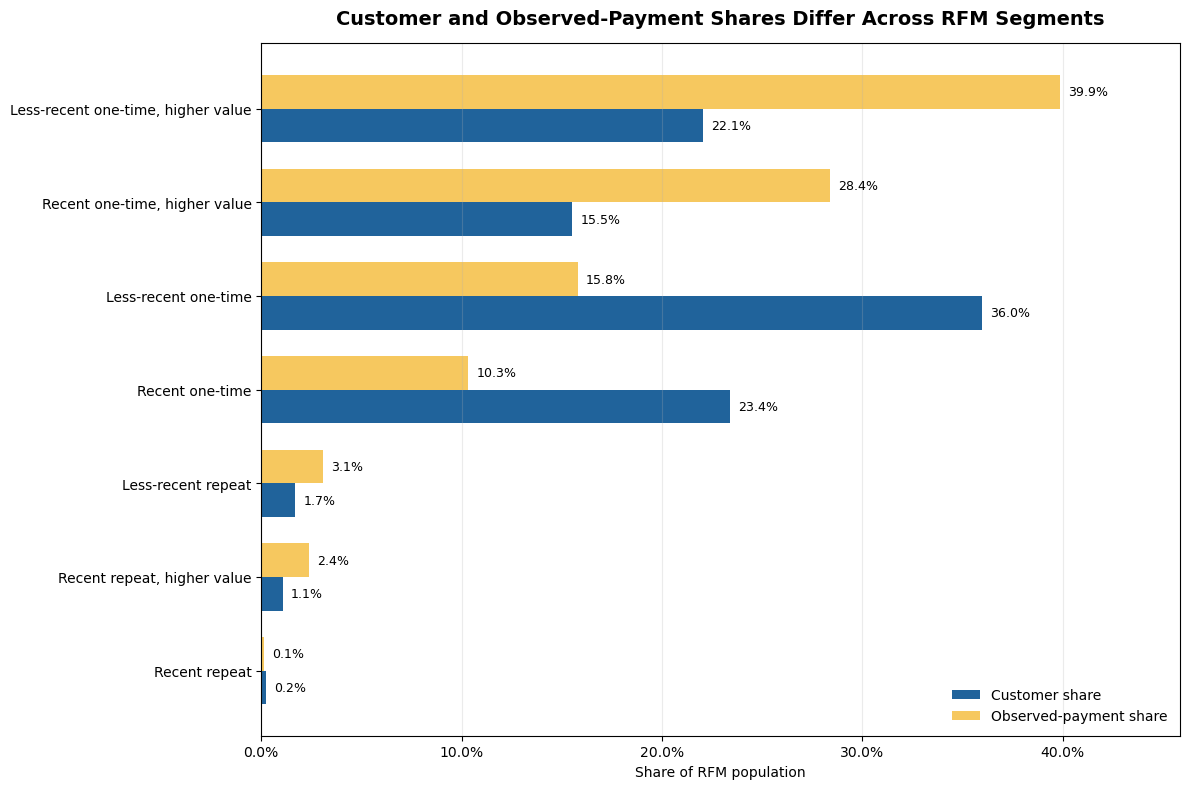

In [6]:
segment_plot = (
    segment_summary
    .sort_values("payment_share")
    .reset_index(drop=True)
)

positions = np.arange(len(segment_plot))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(12, 8))

customer_bars = ax.barh(
    positions - bar_height / 2,
    segment_plot["customer_share"],
    height=bar_height,
    color=COLORS["secondary"],
    label="Customer share"
)

payment_bars = ax.barh(
    positions + bar_height / 2,
    segment_plot["payment_share"],
    height=bar_height,
    color=COLORS["accent"],
    label="Observed-payment share"
)

ax.set_yticks(positions)
ax.set_yticklabels(segment_plot["customer_segment"])

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Share of RFM population")
ax.set_ylabel("")
ax.set_title(
    "Customer and Observed-Payment Shares Differ Across RFM Segments",
    fontsize=14,
    fontweight="bold",
    pad=14
)

for bars in [customer_bars, payment_bars]:
    for bar in bars:
        value = bar.get_width()

        ax.text(
            value + 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1%}",
            va="center",
            fontsize=9
        )

ax.set_xlim(
    0,
    max(
        segment_plot["customer_share"].max(),
        segment_plot["payment_share"].max()
    ) + 0.06
)

ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "rfm_segment_customer_payment_shares.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Higher-value one-time customers account for a larger share of observed payment value than their share of customers. Repeat customers remain a small part of the observed population, reflecting the dataset’s limited repeat-purchase behavior rather than proving customer churn or future retention.

In [7]:
recency_boundaries = (
    rfm
    .groupby("recency_score", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        minimum_recency_days=("recency", "min"),
        maximum_recency_days=("recency", "max"),
        average_recency_days=("recency", "mean")
    )
    .sort_values("recency_score", ascending=False)
)

monetary_boundaries = (
    rfm
    .groupby("monetary_score", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        minimum_observed_payment=("monetary", "min"),
        maximum_observed_payment=("monetary", "max"),
        average_observed_payment=("monetary", "mean")
    )
    .sort_values("monetary_score", ascending=False)
)

frequency_distribution = (
    rfm
    .groupby("frequency_score", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        minimum_orders=("frequency", "min"),
        maximum_orders=("frequency", "max"),
        average_orders=("frequency", "mean")
    )
    .sort_values("frequency_score")
)

print("Recency-score boundaries")
display(
    recency_boundaries.style.format({
        "customers": "{:,.0f}",
        "minimum_recency_days": "{:,.0f}",
        "maximum_recency_days": "{:,.0f}",
        "average_recency_days": "{:,.1f}"
    })
)

print("Frequency-score boundaries")
display(
    frequency_distribution.style.format({
        "customers": "{:,.0f}",
        "minimum_orders": "{:,.0f}",
        "maximum_orders": "{:,.0f}",
        "average_orders": "{:.2f}"
    })
)

print("Monetary-score boundaries")
display(
    monetary_boundaries.style.format({
        "customers": "{:,.0f}",
        "minimum_observed_payment": "R$ {:,.2f}",
        "maximum_observed_payment": "R$ {:,.2f}",
        "average_observed_payment": "R$ {:,.2f}"
    })
)

Recency-score boundaries


,recency_score,customers,minimum_recency_days,maximum_recency_days,average_recency_days
4,5,"18,802",1,93,46.3
3,4,"18,757",94,178,136.6
2,3,"18,723",179,269,221.6
1,2,"18,471",270,383,317.4
0,1,"18,604",384,696,474.1


Frequency-score boundaries


,frequency_score,customers,minimum_orders,maximum_orders,average_orders
0,1,"90,556",1,1,1.00
1,2,"2,573",2,2,2.00
2,3,181,3,3,3.00
3,4,28,4,4,4.00
4,5,19,5,15,6.32


Monetary-score boundaries


,monetary_score,customers,minimum_observed_payment,maximum_observed_payment,average_observed_payment
4,5,"18,668",R$ 208.56,"R$ 13,664.08",R$ 442.15
3,4,"18,675",R$ 132.70,R$ 208.55,R$ 165.17
2,3,"18,658",R$ 87.37,R$ 132.69,R$ 108.52
1,2,"18,683",R$ 55.27,R$ 87.36,R$ 70.53
0,1,"18,673",R$ 9.59,R$ 55.26,R$ 39.70


In [8]:
final_validation = pd.DataFrame([
    {
        "validation_check": "Customer rows represented",
        "result": len(rfm),
        "expected": 93_357
    },
    {
        "validation_check": "Duplicate customer IDs",
        "result": rfm["customer_unique_id"].duplicated().sum(),
        "expected": 0
    },
    {
        "validation_check": "Customers represented by segments",
        "result": segment_summary["customers"].sum(),
        "expected": len(rfm)
    },
    {
        "validation_check": "Delivered orders represented",
        "result": rfm["frequency"].sum(),
        "expected": len(rfm_orders)
    },
    {
        "validation_check": "Observed payment value represented",
        "result": round(rfm["monetary"].sum(), 2),
        "expected": round(
            rfm_orders["total_payment_value"].sum(),
            2
        )
    },
    {
        "validation_check": "Missing customer segments",
        "result": rfm["customer_segment"].isna().sum(),
        "expected": 0
    },
    {
        "validation_check": "Invalid RFM scores",
        "result": (
            (~rfm["recency_score"].between(1, 5)).sum()
            + (~rfm["frequency_score"].between(1, 5)).sum()
            + (~rfm["monetary_score"].between(1, 5)).sum()
        ),
        "expected": 0
    }
])

final_validation["status"] = np.where(
    final_validation["result"]
    == final_validation["expected"],
    "Passed",
    "Failed"
)

display(
    final_validation.style.format({
        "result": lambda value: (
            f"{value:,.2f}"
            if isinstance(value, float)
            else f"{value:,}"
        ),
        "expected": lambda value: (
            f"{value:,.2f}"
            if isinstance(value, float)
            else f"{value:,}"
        )
    })
)

,validation_check,result,expected,status
0,Customer rows represented,"93,357.00","93,357.00",Passed
1,Duplicate customer IDs,0.00,0.00,Passed
2,Customers represented by segments,"93,357.00","93,357.00",Passed
3,Delivered orders represented,"96,477.00","96,477.00",Passed
4,Observed payment value represented,"15,422,461.77","15,422,461.77",Passed
5,Missing customer segments,0.00,0.00,Passed
6,Invalid RFM scores,0.00,0.00,Passed


In [9]:
rfm_export = rfm.copy()

rfm_export.insert(
    1,
    "snapshot_date",
    snapshot_date.date()
)

export_files = {
    "rfm_customer_segments.csv": rfm_export,
    "rfm_segment_summary.csv": segment_summary,
    "rfm_recency_boundaries.csv": recency_boundaries,
    "rfm_frequency_boundaries.csv": frequency_distribution,
    "rfm_monetary_boundaries.csv": monetary_boundaries,
    "rfm_validation_report.csv": final_validation
}

for filename, dataframe in export_files.items():
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in export_files
)

print("RFM files exported:", len(export_files))
print("All RFM files created:", all_files_created)

RFM files exported: 6
All RFM files created: True


## Conclusion

***Key findings:***

- The RFM population contains 93,357 customers and 96,477 delivered orders, representing R$15.42 million in recorded payment value.
- Most customers placed only one delivered order; only 2,801 customers purchased more than once during the observation period.
- Higher-value one-time customers represent 37.60% of customers but 68.27% of observed payment value.
- Recent, higher-value repeat customers represent 1.07% of customers and 2.40% of observed payment value.
- Recency and monetary scores use dataset-specific quintiles, while frequency scores use actual order-count thresholds because frequency is highly concentrated at one order.

***Interpretation:*** These segments describe purchasing behavior observed within the available dataset. They do not identify churn, predict future purchases, or estimate customer lifetime value.

***Outputs:*** Customer-level RFM scores, segment summaries, scoring boundaries, and validation results were exported for reporting and dashboard development.